In [1]:
import os
import pandas as pd

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv')
test_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv')
validation_data = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv')

/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'plots' not in os.listdir():
    os.mkdir('plots')

In [3]:
import torch
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)                   # Python random module
    np.random.seed(seed)                 # NumPy
    torch.manual_seed(seed)              # PyTorch CPU
    torch.cuda.manual_seed(seed)         # PyTorch GPU
    torch.cuda.manual_seed_all(seed)     # If you use multi-GPU
    torch.backends.cudnn.deterministic = True  # Make CUDA deterministic
    torch.backends.cudnn.benchmark = False     # Disable optimization for speed (forces deterministic)

set_seed(42)

In [4]:
train_data

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0
...,...,...,...
148383,99894,just love the jonas brothers its tooo bad i w...,0
148384,61015,another day gone by....time is moving so fast...,0
148385,36598,"fuck college, i'm just gonna marry rich. : fuc...",1
148386,83799,ZOMGZ NEW SONG FTW. remember that night. &lt;3,1


In [5]:
import html
import re

# Function to preprocess text
def preprocess_text(text):
    # Unescape HTML characters
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function to preprocess text
def preprocess_text2(text):
    # Unescape HTML characters
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '<url>', text)
    # Remove mentions
    text = re.sub(r'@\w+', '<user>', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '<hashtag>', text)
    # Remove special characters and numbers except < and >
    # text = re.sub(r'[^a-zA-Z0-9\s<>]', '', text)
    # text = re.sub(r'[^a-zA-Z0-9\s<>\.\,\!\?\:\;\'\"]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to train, test, and validation datasets
train_data['Clean'] = train_data['Text'].apply(preprocess_text)
test_data['Clean'] = test_data['Text'].apply(preprocess_text)
validation_data['Clean'] = validation_data['Text'].apply(preprocess_text)

# Apply preprocessing to train, test, and validation datasets
train_data['Clean2'] = train_data['Text'].apply(preprocess_text2)
test_data['Clean2'] = test_data['Text'].apply(preprocess_text2)
validation_data['Clean2'] = validation_data['Text'].apply(preprocess_text2)

# Display a sample of the cleaned text
train_data[['Text', 'Clean', 'Clean2']]

,Text,Clean,Clean2
0,@whoisralphie dude I'm so bummed ur leaving!,whoisralphie dude im so bummed ur leaving,<user> dude I'm so bummed ur leaving!
1,"oh my god, a severed foot was foun in a wheely...",oh my god a severed foot was foun in a wheely ...,"oh my god, a severed foot was foun in a wheely..."
2,I end up &quot;dog dialing&quot; sumtimes. Wha...,i end up dog dialing sumtimes whats dog dialin...,"I end up ""dog dialing"" sumtimes. What's dog di..."
3,@_rachelx meeeee toooooo!,rachelx meeeee toooooo,<user> meeeee toooooo!
4,"I was hoping I could stay home and work today,...",i was hoping i could stay home and work today ...,"I was hoping I could stay home and work today,..."
...,...,...,...
148383,just love the jonas brothers its tooo bad i w...,just love the jonas brothers its tooo bad i wi...,just love the jonas brothers its tooo bad i wi...
148384,another day gone by....time is moving so fast...,another day gone bytime is moving so fast,another day gone by....time is moving so fast...
148385,"fuck college, i'm just gonna marry rich. : fuc...",fuck college im just gonna marry rich fuck col...,"fuck college, i'm just gonna marry rich. : fuc..."
148386,ZOMGZ NEW SONG FTW. remember that night. &lt;3,zomgz new song ftw remember that night,ZOMGZ NEW SONG FTW. remember that night. <3


In [6]:
from transformers import BertTokenizer

tokenizer1 = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer2 = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [7]:
# Define the special tokens to add
special_tokens = ['<url>', '<user>', '<hashtag>']

# Add the special tokens to the tokenizer
num_added_toks = tokenizer2.add_special_tokens({'additional_special_tokens': special_tokens})

In [8]:
# Tokenize the 'Clean' and 'Clean2' columns
train_data['Tokenized_Clean'] = train_data['Clean'].apply(lambda x: tokenizer1.encode(x, add_special_tokens=True))
train_data['Tokenized_Clean2'] = train_data['Clean2'].apply(lambda x: tokenizer2.encode(x, add_special_tokens=True))

test_data['Tokenized_Clean'] = test_data['Clean'].apply(lambda x: tokenizer1.encode(x, add_special_tokens=True))
test_data['Tokenized_Clean2'] = test_data['Clean2'].apply(lambda x: tokenizer2.encode(x, add_special_tokens=True))

validation_data['Tokenized_Clean'] = validation_data['Clean'].apply(lambda x: tokenizer1.tokenize(x))
validation_data['Tokenized_Clean2'] = validation_data['Clean2'].apply(lambda x: tokenizer2.encode(x, add_special_tokens=True))

# Display a sample of the tokenized text
train_data[['Clean', 'Tokenized_Clean', 'Clean2', 'Tokenized_Clean2']]

,Clean,Tokenized_Clean,Clean2,Tokenized_Clean2
0,whoisralphie dude im so bummed ur leaving,"[101, 2040, 2483, 7941, 21850, 2063, 12043, 10...",<user> dude I'm so bummed ur leaving!,"[101, 30523, 12043, 1045, 1005, 1049, 2061, 26..."
1,oh my god a severed foot was foun in a wheely ...,"[101, 2821, 2026, 2643, 1037, 16574, 3329, 200...","oh my god, a severed foot was foun in a wheely...","[101, 2821, 2026, 2643, 1010, 1037, 16574, 332..."
2,i end up dog dialing sumtimes whats dog dialin...,"[101, 1045, 2203, 2039, 3899, 13764, 2075, 768...","I end up ""dog dialing"" sumtimes. What's dog di...","[101, 1045, 2203, 2039, 1000, 3899, 13764, 207..."
3,rachelx meeeee toooooo,"[101, 5586, 2595, 2033, 4402, 4402, 2205, 9541...",<user> meeeee toooooo!,"[101, 30523, 2033, 4402, 4402, 2205, 9541, 954..."
4,i was hoping i could stay home and work today ...,"[101, 1045, 2001, 5327, 1045, 2071, 2994, 2188...","I was hoping I could stay home and work today,...","[101, 1045, 2001, 5327, 1045, 2071, 2994, 2188..."
...,...,...,...,...
148383,just love the jonas brothers its tooo bad i wi...,"[101, 2074, 2293, 1996, 10680, 3428, 2049, 220...",just love the jonas brothers its tooo bad i wi...,"[101, 2074, 2293, 1996, 10680, 3428, 2049, 220..."
148384,another day gone bytime is moving so fast,"[101, 2178, 2154, 2908, 2011, 7292, 2003, 3048...",another day gone by....time is moving so fast...,"[101, 2178, 2154, 2908, 2011, 1012, 1012, 1012..."
148385,fuck college im just gonna marry rich fuck col...,"[101, 6616, 2267, 10047, 2074, 6069, 5914, 413...","fuck college, i'm just gonna marry rich. : fuc...","[101, 6616, 2267, 1010, 1045, 1005, 1049, 2074..."
148386,zomgz new song ftw remember that night,"[101, 1062, 5358, 2290, 2480, 2047, 2299, 3027...",ZOMGZ NEW SONG FTW. remember that night. <3,"[101, 1062, 5358, 2290, 2480, 2047, 2299, 3027..."


In [9]:
train_data['Tokenized_Clean'].map(len).describe(), train_data['Tokenized_Clean2'].map(len).describe()

(count    148388.000000
 mean         18.007905
 std           7.949658
 min           2.000000
 25%          12.000000
 50%          17.000000
 75%          24.000000
 max          59.000000
 Name: Tokenized_Clean, dtype: float64,
 count    148388.000000
 mean         20.322951
 std           9.921036
 min           3.000000
 25%          12.000000
 50%          19.000000
 75%          27.000000
 max         256.000000
 Name: Tokenized_Clean2, dtype: float64)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


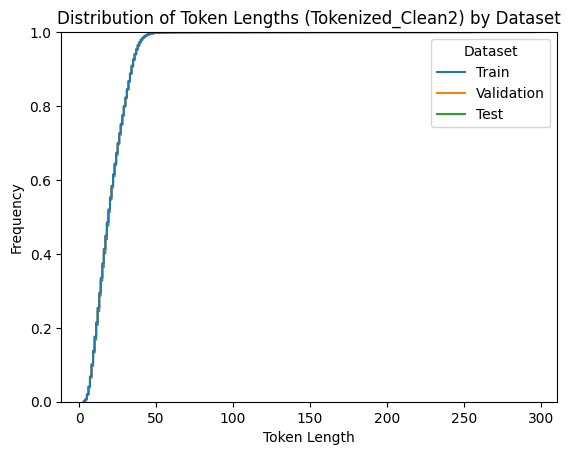

In [10]:
# Calculate token lengths for Tokenized_Clean2
train_data['Tokenized_Clean2_Length'] = train_data['Tokenized_Clean2'].map(len)
validation_data['Tokenized_Clean2_Length'] = validation_data['Tokenized_Clean2'].map(len)
test_data['Tokenized_Clean2_Length'] = test_data['Tokenized_Clean2'].map(len)

train_data['Dataset'] = 'Train'
validation_data['Dataset'] = 'Validation'
test_data['Dataset'] = 'Test'
# Concatenate all token lengths for Tokenized_Clean2
all_token_lengths_clean2 = pd.concat([train_data[['Tokenized_Clean2_Length', 'Dataset']],
                                     validation_data[['Tokenized_Clean2_Length', 'Dataset']],
                                     test_data[['Tokenized_Clean2_Length', 'Dataset']]])

# Prepare the combined DataFrame for plotting
all_token_lengths2 = pd.concat([train_data[['Tokenized_Clean2_Length', 'Dataset']],
                                 validation_data[['Tokenized_Clean2_Length', 'Dataset']],
                                 test_data[['Tokenized_Clean2_Length', 'Dataset']]])

# Plotting the distribution of token lengths for all datasets, varying hue by dataset
# plt.figure(figsize=(10, 6))
sns.ecdfplot(data=all_token_lengths2, x='Tokenized_Clean2_Length', hue='Dataset')
plt.title('Distribution of Token Lengths (Tokenized_Clean2) by Dataset')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.savefig('plots/token_length_distribution_clean2_by_dataset.png', dpi=300)
plt.show()

In [11]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
def tokenize_and_encode(text, tokenizer, max_len):
    encoded = tokenizer.encode_plus(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_attention_mask=True,
        return_tensors='pt'  # Return PyTorch tensors
    )
    return encoded['input_ids'].squeeze(), encoded['attention_mask'].squeeze() # Return as tensors


In [13]:
max_length = train_data['Tokenized_Clean'].map(len).max()

train_data['Tokenized_Clean'], train_data['Attention_Mask_Clean'] = zip(*train_data['Clean'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))
test_data['Tokenized_Clean'], test_data['Attention_Mask_Clean'] = zip(*test_data['Clean'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))
validation_data['Tokenized_Clean'], validation_data['Attention_Mask_Clean'] = zip(*validation_data['Clean'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))

# Display a sample of the encoded data (showing input_ids and attention_mask)
print("Sample of encoded train data:")
print(train_data[['Clean', 'Tokenized_Clean', 'Attention_Mask_Clean']].head())

print("\nSample of encoded test data:")
print(test_data[['Clean', 'Tokenized_Clean', 'Attention_Mask_Clean']].head())

print("\nSample of encoded validation data:")
print(validation_data[['Clean', 'Tokenized_Clean', 'Attention_Mask_Clean']].head())

print("\nShape of encoded data (first element):")
print(train_data['Tokenized_Clean'].iloc[0].shape)
print(train_data['Attention_Mask_Clean'].iloc[0].shape)

Sample of encoded train data:
                                               Clean  \
0          whoisralphie dude im so bummed ur leaving   
1  oh my god a severed foot was foun in a wheely ...   
2  i end up dog dialing sumtimes whats dog dialin...   
3                             rachelx meeeee toooooo   
4  i was hoping i could stay home and work today ...   

                                     Tokenized_Clean  \
0  [tensor(101), tensor(2040), tensor(2483), tens...   
1  [tensor(101), tensor(2821), tensor(2026), tens...   
2  [tensor(101), tensor(1045), tensor(2203), tens...   
3  [tensor(101), tensor(5586), tensor(2595), tens...   
4  [tensor(101), tensor(1045), tensor(2001), tens...   

                                Attention_Mask_Clean  
0  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
1  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
2  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
3  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
4  [tensor(1), tensor

In [14]:
max_length = 64

train_data['Tokenized_Clean2'], train_data['Attention_Mask_Clean2'] = zip(*train_data['Clean2'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))
test_data['Tokenized_Clean2'], test_data['Attention_Mask_Clean2'] = zip(*test_data['Clean2'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))
validation_data['Tokenized_Clean2'], validation_data['Attention_Mask_Clean2'] = zip(*validation_data['Clean2'].apply(lambda x: tokenize_and_encode(x, tokenizer2, max_length)))

# Display a sample of the encoded data (showing input_ids and attention_mask)
print("Sample of encoded train data:")
print(train_data[['Clean2', 'Tokenized_Clean2', 'Attention_Mask_Clean2']].head())

print("\nSample of encoded test data:")
print(test_data[['Clean2', 'Tokenized_Clean2', 'Attention_Mask_Clean2']].head())

print("\nSample of encoded validation data:")
print(validation_data[['Clean2', 'Tokenized_Clean2', 'Attention_Mask_Clean2']].head())

print("\nShape of encoded data (first element):")
print(train_data['Tokenized_Clean2'].iloc[0].shape)
print(train_data['Attention_Mask_Clean2'].iloc[0].shape)

Sample of encoded train data:
                                              Clean2  \
0              <user> dude I'm so bummed ur leaving!   
1  oh my god, a severed foot was foun in a wheely...   
2  I end up "dog dialing" sumtimes. What's dog di...   
3                             <user> meeeee toooooo!   
4  I was hoping I could stay home and work today,...   

                                    Tokenized_Clean2  \
0  [tensor(101), tensor(30523), tensor(12043), te...   
1  [tensor(101), tensor(2821), tensor(2026), tens...   
2  [tensor(101), tensor(1045), tensor(2203), tens...   
3  [tensor(101), tensor(30523), tensor(2033), ten...   
4  [tensor(101), tensor(1045), tensor(2001), tens...   

                               Attention_Mask_Clean2  
0  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
1  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
2  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
3  [tensor(1), tensor(1), tensor(1), tensor(1), t...  
4  [tensor(1), tensor

In [15]:

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

# Convert lists of tensors to single tensors
train_inputs_clean = torch.stack(list(train_data['Tokenized_Clean']))
train_masks_clean = torch.stack(list(train_data['Attention_Mask_Clean']))
train_labels = torch.tensor(train_data['Label'].values)

validation_inputs_clean = torch.stack(list(validation_data['Tokenized_Clean']))
validation_masks_clean = torch.stack(list(validation_data['Attention_Mask_Clean']))
validation_labels = torch.tensor(validation_data['Label'].values)

test_inputs_clean = torch.stack(list(test_data['Tokenized_Clean']))
test_masks_clean = torch.stack(list(test_data['Attention_Mask_Clean']))
test_labels = torch.tensor([0.0] * len(test_data))

train_inputs_clean2 = torch.stack(list(train_data['Tokenized_Clean2']))
train_masks_clean2 = torch.stack(list(train_data['Attention_Mask_Clean2']))

validation_inputs_clean2 = torch.stack(list(validation_data['Tokenized_Clean2']))
validation_masks_clean2 = torch.stack(list(validation_data['Attention_Mask_Clean2']))

test_inputs_clean2 = torch.stack(list(test_data['Tokenized_Clean2']))
test_masks_clean2 = torch.stack(list(test_data['Attention_Mask_Clean2']))

# Create TensorDatasets
train_dataset_clean = TensorDataset(train_inputs_clean, train_masks_clean, train_labels)
validation_dataset_clean = TensorDataset(validation_inputs_clean, validation_masks_clean, validation_labels)
test_dataset_clean = TensorDataset(test_inputs_clean, test_masks_clean, test_labels)

train_dataset_clean2 = TensorDataset(train_inputs_clean2, train_masks_clean2, train_labels)
validation_dataset_clean2 = TensorDataset(validation_inputs_clean2, validation_masks_clean2, validation_labels)
test_dataset_clean2 = TensorDataset(test_inputs_clean2, test_masks_clean2, test_labels)

# Define batch size
batch_size = 32

# Create DataLoaders for Tokenized_Clean
train_dataloader_clean = DataLoader(train_dataset_clean, batch_size=batch_size, shuffle=True)
validation_dataloader_clean = DataLoader(validation_dataset_clean, batch_size=batch_size)
test_dataloader_clean = DataLoader(test_dataset_clean, batch_size=batch_size)

# Create DataLoaders for Tokenized_Clean2
train_dataloader_clean2 = DataLoader(train_dataset_clean2, batch_size=batch_size, shuffle=True)
validation_dataloader_clean2 = DataLoader(validation_dataset_clean2, batch_size=batch_size)
test_dataloader_clean2 = DataLoader(test_dataset_clean2, batch_size=batch_size)

print("\nDataLoaders created:")
print(f"train_dataloader_clean: {len(train_dataloader_clean)} batches")
print(f"validation_dataloader_clean: {len(validation_dataloader_clean)} batches")
print(f"test_dataloader_clean: {len(test_dataloader_clean)} batches")
print(f"train_dataloader_clean2: {len(train_dataloader_clean2)} batches")
print(f"validation_dataloader_clean2: {len(validation_dataloader_clean2)} batches")
print(f"test_dataloader_clean2: {len(test_dataloader_clean2)} batches")



DataLoaders created:
train_dataloader_clean: 4638 batches
validation_dataloader_clean: 1325 batches
test_dataloader_clean: 663 batches
train_dataloader_clean2: 4638 batches
validation_dataloader_clean2: 1325 batches
test_dataloader_clean2: 663 batches


In [16]:
import datetime

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [17]:
import time

def train_and_validate(model, train_dataloader, validation_dataloader, optimizer, scheduler, device, epochs=2):
    training_stats = []

    # Measure the total training time for the whole run.
    total_t0 = time.time()

    # For each epoch...
    for epoch_i in range(0, epochs):

        # ========================================
        #               Training
        # ========================================

        # Perform one full pass over the training set.

        print("")
        print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
        print('Training...')

        # Measure how long the training epoch takes.
        t0 = time.time()

        # Reset the total loss for this epoch.
        total_train_loss = 0
        total_train_correct = 0

        # Put the model into training mode. Don't be mislead--the call to
        # `train` just changes the *mode*, it doesn't *perform* the training.
        # `dropout` and `batchnorm` layers behave differently during training
        # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
        model.train()

        # For each batch of training data...
        for step, batch in enumerate(train_dataloader):

            # Progress update every 40 batches.
            if step % 40 == 0 and not step == 0:
                # Calculate elapsed time in minutes.
                elapsed = format_time(time.time() - t0)

                # Report progress.
                print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

            # Unpack this training batch from our dataloader.
            #
            # As we unpack the batch, we'll also copy each tensor to the GPU using the
            # `to` method.
            #
            # `batch` contains three pytorch tensors:
            #   [0]: input ids
            #   [1]: attention masks
            #   [2]: labels
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_labels = batch[2].to(device)

            # Always clear any previously calculated gradients before performing a
            # backward pass. PyTorch doesn't do this automatically because
            # accumulating the gradients is "convenient while training RNNs".
            # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
            model.zero_grad()

            # Perform a forward pass (evaluate the model on this training batch).
            # In PyTorch, calling `model` will in turn call the model's `forward`
            # function and pass down the arguments. The `forward` function is
            # documented here:
            # https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification
            # The results are returned in a results object, documented here:
            # https://huggingface.co/transformers/main_classes/output.html#transformers.modeling_outputs.SequenceClassifierOutput
            # Specifically, we'll get the loss (because we provided labels) and the
            # "logits"--the model outputs prior to activation (the scores).
            result = model(b_input_ids,
                        attention_mask=b_input_mask,
                        labels=b_labels,
                        return_dict=True)

            loss = result.loss
            logits = result.logits

            # Accumulate the training loss over all of the batches so that we can
            # calculate the average loss at the end. `loss` is a Tensor containing a
            # single value; the `.item()` function just returns the Python value
            # from the tensor.
            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()
            total_train_correct += flat_accuracy(logits, label_ids)
            total_train_loss += loss.item()

            # Perform a backward pass to calculate the gradients.
            loss.backward()

            # Clip the norm of the gradients to 1.0.
            # This is to help prevent the "exploding gradients" problem.
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update parameters and take a step using the computed gradient.
            # The optimizer dictates the "update rule"--how the parameters are
            # modified based on their gradients, the learning rate, etc.
            optimizer.step()

            # Update the learning rate.
            scheduler.step()

        # Calculate the average loss over all of the batches.
        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_acc = total_train_correct / len(train_dataloader)

        # Measure how long this epoch took.
        training_time = format_time(time.time() - t0)

        print("")
        print("  Average training loss: {0:.2f}".format(avg_train_loss))
        print("  Average training accuracy: {0:.2f}".format(avg_train_acc))
        print("  Training epcoh took: {:}".format(training_time))

        # ========================================
        #               Validation
        # ========================================
        # After the completion of each training epoch, measure our performance on
        # our validation set.

        print("")
        print("Running Validation...")

        t0 = time.time()

        # Put the model in evaluation mode--the dropout layers behave differently
        # during evaluation.
        model.eval()

        # Tracking variables
        total_eval_accuracy = 0
        total_eval_loss = 0
        nb_eval_steps = 0

        # Evaluate data for one epoch
        for batch in validation_dataloader:

            # Unpack this training batch from our dataloader.
            #
            # As we unpack the batch, we'll also copy each tensor to the GPU using
            # the `to` method.
            #
            # `batch` contains three pytorch tensors:
            #   [0]: input ids
            #   [1]: attention masks
            #   [2]: labels
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_labels = batch[2].to(device)

            # Tell pytorch not to bother with constructing the compute graph during
            # the forward pass, since this is only needed for backprop (training).
            with torch.no_grad():

                # Forward pass, calculate logit predictions.
                # token_type_ids is the same as the "segment ids", which
                # differentiates sentence 1 and 2 in 2-sentence tasks.
                result = model(b_input_ids,
                            attention_mask=b_input_mask,
                            labels=b_labels,
                            return_dict=True)

            # Get the loss and "logits" output by the model. The "logits" are the
            # output values prior to applying an activation function like the
            # softmax.
            loss = result.loss
            logits = result.logits

            # Accumulate the validation loss.
            total_eval_loss += loss.item()

            # Move logits and labels to CPU
            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            # Calculate the accuracy for this batch of test sentences, and
            # accumulate it over all batches.
            total_eval_accuracy += flat_accuracy(logits, label_ids)


        # Report the final accuracy for this validation run.
        avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
        print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

        # Calculate the average loss over all of the batches.
        avg_val_loss = total_eval_loss / len(validation_dataloader)

        # Measure how long the validation run took.
        validation_time = format_time(time.time() - t0)

        print("  Validation Loss: {0:.2f}".format(avg_val_loss))
        print("  Validation took: {:}".format(validation_time))

        # Record all statistics from this epoch.
        training_stats.append(
            {
                'epoch': epoch_i + 1,
                'Training Accur.': avg_train_acc,
                'Training Loss': avg_train_loss,
                'Valid. Loss': avg_val_loss,
                'Valid. Accur.': avg_val_accuracy,
                'Training Time': training_time,
                'Validation Time': validation_time
            }
        )

    print("")
    print("Training complete!")

    print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))
    return training_stats


In [18]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, name=None):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Loss/Accuracy')
    plt.title('Training and Validation Metrics')
    plt.legend()
    plt.grid(True)
    if name:
        plt.savefig(name, dpi=300)
    plt.show()

In [19]:
import torch.nn.functional as F
from sklearn.metrics import classification_report

def extract_metrics(model, validation_loader, device):
  model.eval()  # Set the model to evaluation mode
  y_true = []
  y_pred = []
  y_proba = []

  for batch in validation_loader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
      outputs = model(b_input_ids,
                      attention_mask=b_input_mask)

    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)

    # Move to CPU and convert to numpy arrays
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    probabilities = probabilities.detach().cpu().numpy()

    # Store results
    y_true.extend(label_ids)
    y_pred.extend(np.argmax(logits, axis=1).flatten())
    y_proba.extend(probabilities)

  return np.array(y_true), np.array(y_pred), np.array(y_proba)[:, 1]

In [20]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def get_model(resize_embeddings=False, device='cuda'):
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels = 2,
        output_attentions = False,
        output_hidden_states = False,
    )
    if resize_embeddings:
        model.bert.resize_token_embeddings(len(tokenizer2))
    model.to(device)
    return model

2025-06-01 23:20:53.376723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748820053.629240      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748820053.700660      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [21]:
model1 = get_model(device=device)
epochs = 2

optimizer = AdamW(model1.parameters(), lr = 1e-5, eps = 1e-8)
total_steps = len(train_dataloader_clean) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)
results1 = train_and_validate(model1, train_dataloader_clean, validation_dataloader_clean, optimizer, scheduler, device, epochs)
y_true1, y_pred1, y_proba1 = extract_metrics(model1, validation_dataloader_clean, device)
print(classification_report(y_true1, y_pred1))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  4,638.    Elapsed: 0:00:08.
  Batch    80  of  4,638.    Elapsed: 0:00:15.
  Batch   120  of  4,638.    Elapsed: 0:00:23.
  Batch   160  of  4,638.    Elapsed: 0:00:30.
  Batch   200  of  4,638.    Elapsed: 0:00:38.
  Batch   240  of  4,638.    Elapsed: 0:00:45.
  Batch   280  of  4,638.    Elapsed: 0:00:52.
  Batch   320  of  4,638.    Elapsed: 0:01:00.
  Batch   360  of  4,638.    Elapsed: 0:01:07.
  Batch   400  of  4,638.    Elapsed: 0:01:15.
  Batch   440  of  4,638.    Elapsed: 0:01:22.
  Batch   480  of  4,638.    Elapsed: 0:01:29.
  Batch   520  of  4,638.    Elapsed: 0:01:37.
  Batch   560  of  4,638.    Elapsed: 0:01:44.
  Batch   600  of  4,638.    Elapsed: 0:01:52.
  Batch   640  of  4,638.    Elapsed: 0:01:59.
  Batch   680  of  4,638.    Elapsed: 0:02:06.
  Batch   720  of  4,638.    Elapsed: 0:02:14.
  Batch   760  of  4,638.    Elapsed: 0:02:21.
  Batch   800  of  4,638.    Elapsed: 0:02:29.
  Batch   840  of

In [22]:
model2 = get_model(resize_embeddings=True)
epochs = 2

optimizer = AdamW(model2.parameters(), lr = 1e-5, eps = 1e-8)
total_steps = len(train_dataloader_clean2) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)
results2 = train_and_validate(model2, train_dataloader_clean2, validation_dataloader_clean2, optimizer, scheduler, device, epochs)
y_true2, y_pred2, y_proba2 = extract_metrics(model2, validation_dataloader_clean2, device)
print(classification_report(y_true2, y_pred2))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  4,638.    Elapsed: 0:00:08.
  Batch    80  of  4,638.    Elapsed: 0:00:16.
  Batch   120  of  4,638.    Elapsed: 0:00:23.
  Batch   160  of  4,638.    Elapsed: 0:00:31.
  Batch   200  of  4,638.    Elapsed: 0:00:39.
  Batch   240  of  4,638.    Elapsed: 0:00:47.
  Batch   280  of  4,638.    Elapsed: 0:00:55.
  Batch   320  of  4,638.    Elapsed: 0:01:03.
  Batch   360  of  4,638.    Elapsed: 0:01:11.
  Batch   400  of  4,638.    Elapsed: 0:01:18.
  Batch   440  of  4,638.    Elapsed: 0:01:26.
  Batch   480  of  4,638.    Elapsed: 0:01:34.
  Batch   520  of  4,638.    Elapsed: 0:01:42.
  Batch   560  of  4,638.    Elapsed: 0:01:50.
  Batch   600  of  4,638.    Elapsed: 0:01:58.
  Batch   640  of  4,638.    Elapsed: 0:02:06.
  Batch   680  of  4,638.    Elapsed: 0:02:13.
  Batch   720  of  4,638.    Elapsed: 0:02:21.
  Batch   760  of  4,638.    Elapsed: 0:02:29.
  Batch   800  of  4,638.    Elapsed: 0:02:37.
  Batch   840  of

In [23]:
# Define batch size
batch_size = 16

# Create DataLoaders for Tokenized_Clean2
train_dataloader_clean3 = DataLoader(train_dataset_clean2, batch_size=batch_size, shuffle=True)
validation_dataloader_clean3 = DataLoader(validation_dataset_clean2, batch_size=batch_size)
test_dataloader_clean3 = DataLoader(test_dataset_clean2, batch_size=batch_size)

In [24]:
model3 = get_model(resize_embeddings=True)
epochs = 2

optimizer = AdamW(model3.parameters(), lr = 1e-5, eps = 1e-8)
total_steps = len(train_dataloader_clean3) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)
results3 = train_and_validate(model3, train_dataloader_clean3, validation_dataloader_clean3, optimizer, scheduler, device, epochs)
y_true3, y_pred3, y_proba3 = extract_metrics(model3, validation_dataloader_clean3, device)
print(classification_report(y_true3, y_pred3))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  9,275.    Elapsed: 0:00:05.
  Batch    80  of  9,275.    Elapsed: 0:00:09.
  Batch   120  of  9,275.    Elapsed: 0:00:14.
  Batch   160  of  9,275.    Elapsed: 0:00:18.
  Batch   200  of  9,275.    Elapsed: 0:00:23.
  Batch   240  of  9,275.    Elapsed: 0:00:27.
  Batch   280  of  9,275.    Elapsed: 0:00:32.
  Batch   320  of  9,275.    Elapsed: 0:00:37.
  Batch   360  of  9,275.    Elapsed: 0:00:41.
  Batch   400  of  9,275.    Elapsed: 0:00:46.
  Batch   440  of  9,275.    Elapsed: 0:00:50.
  Batch   480  of  9,275.    Elapsed: 0:00:55.
  Batch   520  of  9,275.    Elapsed: 0:01:00.
  Batch   560  of  9,275.    Elapsed: 0:01:04.
  Batch   600  of  9,275.    Elapsed: 0:01:09.
  Batch   640  of  9,275.    Elapsed: 0:01:13.
  Batch   680  of  9,275.    Elapsed: 0:01:18.
  Batch   720  of  9,275.    Elapsed: 0:01:22.
  Batch   760  of  9,275.    Elapsed: 0:01:27.
  Batch   800  of  9,275.    Elapsed: 0:01:32.
  Batch   840  of

In [25]:
accuracy_model2 = results2[-1]['Valid. Accur.']
accuracy_model3 = results3[-1]['Valid. Accur.']

if accuracy_model3 > accuracy_model2:
  print("Model 3 is better than Model 2. Keeping dataset3.")
  best_train_dataloader = train_dataloader_clean3
  best_val_dataloader = validation_dataloader_clean3
  best_test_dataloader = test_dataloader_clean3
else:
  print("Model 2 is better than Model 3. Keeping dataset2.")
  best_train_dataloader = train_dataloader_clean2
  best_val_dataloader = validation_dataloader_clean2
  best_test_dataloader = test_dataloader_clean2


Model 3 is better than Model 2. Keeping dataset3.


In [26]:
!pip install optuna

import optuna
from sklearn.metrics import accuracy_score

def objective(trial):
    # Define hyperparameters to tune
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.0, 0.1)

    # Get the model
    model = get_model(resize_embeddings=True, device=device)
    model.train()

    # Define optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=learning_rate, eps=eps)
    total_steps = len(best_train_dataloader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    _results = train_and_validate(model, best_train_dataloader, best_val_dataloader, optimizer, scheduler, device, 2)

    return _results[-1]['Valid. Accur.']

# Create a study and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # Run 10 trials

# Print the best parameters and their value
print("Best trial:")
print("  Value: {}".format(study.best_trial.value))
print("  Params: ")
for key, value in study.best_trial.params.items():
    print("    {}: {}".format(key, value))


[I 2025-06-02 01:06:49,268] A new study created in memory with name: no-name-49c9b7c0-9143-4150-b4e2-f230613fd5b9
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  9,275.    Elapsed: 0:00:05.
  Batch    80  of  9,275.    Elapsed: 0:00:09.
  Batch   120  of  9,275.    Elapsed: 0:00:14.
  Batch   160  of  9,275.    Elapsed: 0:00:18.
  Batch   200  of  9,275.    Elapsed: 0:00:23.
  Batch   240  of  9,275.    Elapsed: 0:00:27.
  Batch   280  of  9,275.    Elapsed: 0:00:32.
  Batch   320  of  9,275.    Elapsed: 0:00:37.
  Batch   360  of  9,275.    Elapsed: 0:00:41.
  Batch   400  of  9,275.    Elapsed: 0:00:46.
  Batch   440  of  9,275.    Elapsed: 0:00:50.
  Batch   480  of  9,275.    Elapsed: 0:00:55.
  Batch   520  of  9,275.    Elapsed: 0:00:59.
  Batch   560  of  9,275.    Elapsed: 0:01:04.
  Batch   600  of  9,275.    Elapsed: 0:01:09.
  Batch   640  of  9,275.    Elapsed: 0:01:13.
  Batch   680  of  9,275.    Elapsed: 0:01:18.
  Batch   720  of  9,275.    Elapsed: 0:01:22.
  Batch   760  of  9,275.    Elapsed: 0:01:27.
  Batch   800  of  9,275.    Elapsed: 0:01:31.
  Batch   840  of

[I 2025-06-02 01:44:42,060] Trial 0 finished with value: 0.857877358490566 and parameters: {'learning_rate': 1.6419398165784973e-05, 'eps': 8.459911459807864e-09, 'warmup_ratio': 0.033920807352444494}. Best is trial 0 with value: 0.857877358490566.


  Accuracy: 0.86
  Validation Loss: 0.37
  Validation took: 0:01:20

Training complete!
Total training took 0:37:52 (h:mm:ss)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  Accuracy: 0.85
  Validation Loss: 0.36
  Validation took: 0:01:20

Training complete!
Total training took 0:38:02 (h:mm:ss)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  9,275.    Elapsed: 0:00:05.
  Batch    80  of  9,275.    Elapsed: 0:00:09.
  Batch   120  of  9,275.    Elapsed: 0:00:14.
  Batch   160  of  9,275.    Elapsed: 0:00:18.
  Batch   200  of  9,275.    Elapsed: 0:00:23.
  Batch   240  of  9,275.    Elapsed: 0:00:27.
  Batch   280  of  9,275.    Elapsed: 0:00:32.
  Batch   320  of  9,275.    Elapsed: 0:00:37.
  Batch   360  of  9,275.    Elapsed: 0:00:41.
  Batch   400  of  9,275.    Elapsed: 0:00:46.
  Batch   440  of  9,275.    Elapsed: 0:00:50.
  Batch   480  of  9,275.    Elapsed: 0:00:55.
  Batch   520  of  9,275.    Elapsed: 0:00:59.
  Batch   560  of  9,275.    Elapsed: 0:01:04.
  Batch   600  of  9,275.    Elapsed: 0:01:09.
  Batch   640  of  9,275.    Elapsed: 0:01:13.
  Batch   680  of  9,275.    Elapsed: 0:01:18.
  Batch   720  of  9,275.    Elapsed: 0:01:22.
  Batch   760  of  9,275.    Elapsed: 0:01:27.
  Batch   800  of  9,275.    Elapsed: 0:01:31.
  Batch   840  of

[I 2025-06-02 07:26:00,410] Trial 9 finished with value: 0.8571933962264151 and parameters: {'learning_rate': 2.2560075873976092e-05, 'eps': 2.056584362440563e-09, 'warmup_ratio': 0.08265341604837717}. Best is trial 0 with value: 0.857877358490566.


  Accuracy: 0.86
  Validation Loss: 0.36
  Validation took: 0:01:20

Training complete!
Total training took 0:37:59 (h:mm:ss)
Best trial:
  Value: 0.857877358490566
  Params: 
    learning_rate: 1.6419398165784973e-05
    eps: 8.459911459807864e-09
    warmup_ratio: 0.033920807352444494


In [27]:
best_params = study.best_trial.params


final_epochs = 2


best_model = get_model(resize_embeddings=True, device=device)
best_model.train()

# Define optimizer and scheduler with the best hyperparameters
best_optimizer = AdamW(best_model.parameters(), lr=best_params['learning_rate'], eps=best_params['eps'])

total_steps = len(best_train_dataloader) * final_epochs
warmup_steps = int(total_steps * best_params['warmup_ratio'])

best_scheduler = get_linear_schedule_with_warmup(best_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

results4 = train_and_validate(best_model, best_train_dataloader, best_val_dataloader, best_optimizer, best_scheduler, device, epochs=final_epochs)
y_true4, y_pred4, y_proba4 = extract_metrics(best_model, best_val_dataloader, device)
print(classification_report(y_true4, y_pred4))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch    40  of  9,275.    Elapsed: 0:00:04.
  Batch    80  of  9,275.    Elapsed: 0:00:09.
  Batch   120  of  9,275.    Elapsed: 0:00:14.
  Batch   160  of  9,275.    Elapsed: 0:00:18.
  Batch   200  of  9,275.    Elapsed: 0:00:23.
  Batch   240  of  9,275.    Elapsed: 0:00:27.
  Batch   280  of  9,275.    Elapsed: 0:00:32.
  Batch   320  of  9,275.    Elapsed: 0:00:36.
  Batch   360  of  9,275.    Elapsed: 0:00:41.
  Batch   400  of  9,275.    Elapsed: 0:00:45.
  Batch   440  of  9,275.    Elapsed: 0:00:50.
  Batch   480  of  9,275.    Elapsed: 0:00:55.
  Batch   520  of  9,275.    Elapsed: 0:00:59.
  Batch   560  of  9,275.    Elapsed: 0:01:04.
  Batch   600  of  9,275.    Elapsed: 0:01:08.
  Batch   640  of  9,275.    Elapsed: 0:01:13.
  Batch   680  of  9,275.    Elapsed: 0:01:17.
  Batch   720  of  9,275.    Elapsed: 0:01:22.
  Batch   760  of  9,275.    Elapsed: 0:01:26.
  Batch   800  of  9,275.    Elapsed: 0:01:31.
  Batch   840  of

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_true1, y_pred1))

print(classification_report(y_true2, y_pred2))

print(classification_report(y_true3, y_pred3))

print(classification_report(y_true4, y_pred4))


              precision    recall  f1-score   support

           0       0.83      0.85      0.84     21197
           1       0.85      0.83      0.84     21199

    accuracy                           0.84     42396
   macro avg       0.84      0.84      0.84     42396
weighted avg       0.84      0.84      0.84     42396

              precision    recall  f1-score   support

           0       0.85      0.86      0.85     21197
           1       0.86      0.85      0.85     21199

    accuracy                           0.85     42396
   macro avg       0.85      0.85      0.85     42396
weighted avg       0.85      0.85      0.85     42396

              precision    recall  f1-score   support

           0       0.85      0.86      0.85     21197
           1       0.86      0.85      0.85     21199

    accuracy                           0.85     42396
   macro avg       0.85      0.85      0.85     42396
weighted avg       0.85      0.85      0.85     42396

              preci

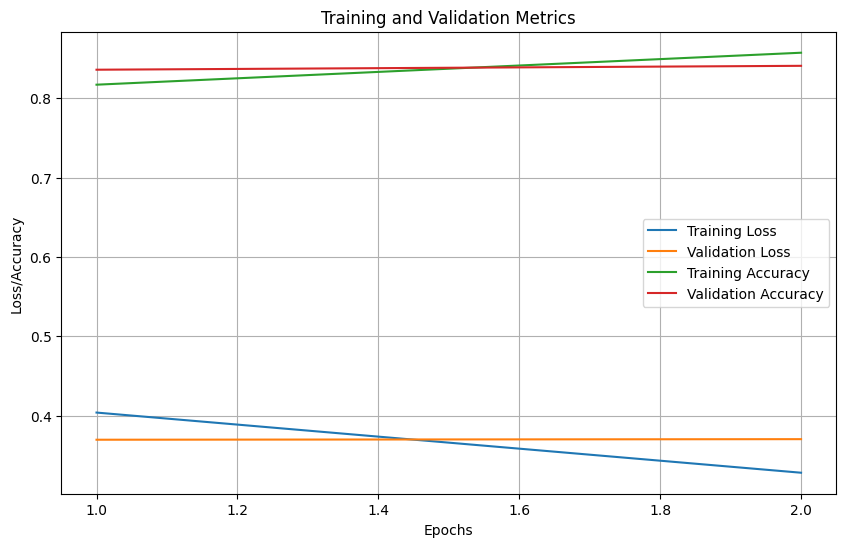

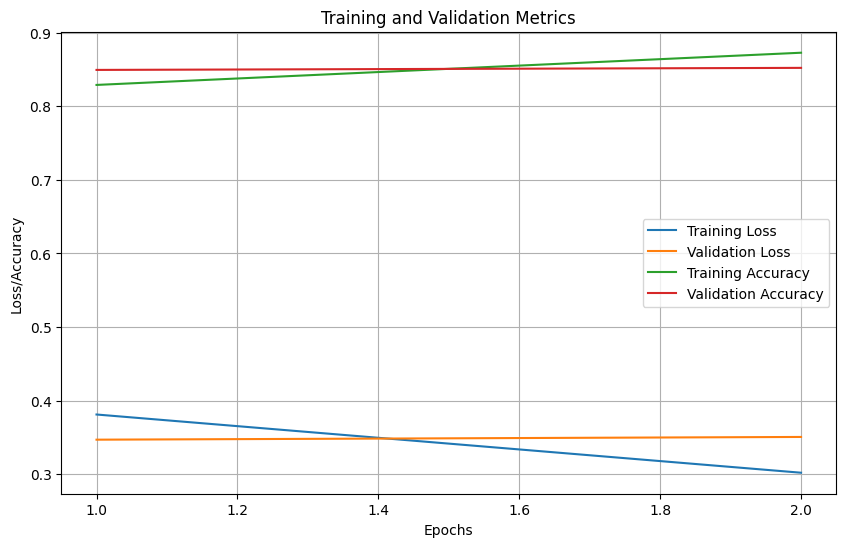

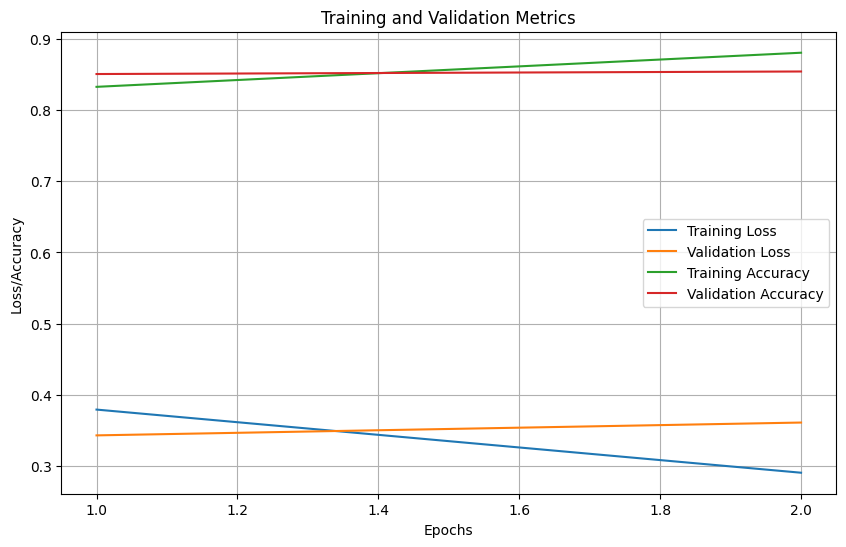

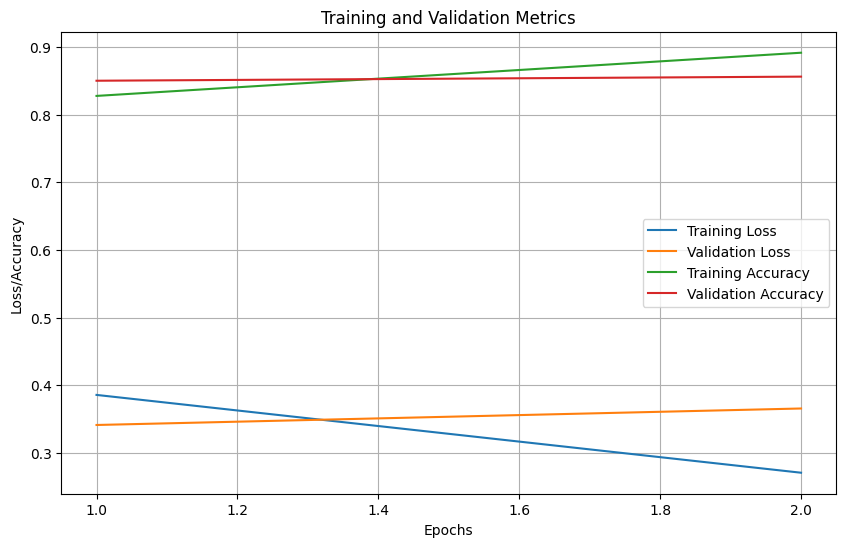

In [29]:
results1 = pd.DataFrame(results1)
results2 = pd.DataFrame(results2)
results3 = pd.DataFrame(results3)
results4 = pd.DataFrame(results4)

plot_metrics(results1['Training Loss'].to_list(), results1['Valid. Loss'].to_list(), results1['Training Accur.'].to_list(), results1['Valid. Accur.'].to_list(), name='plots/curve_model1.png')
plot_metrics(results2['Training Loss'].to_list(), results2['Valid. Loss'].to_list(), results2['Training Accur.'].to_list(), results2['Valid. Accur.'].to_list(), name='plots/curve_model2.png')
plot_metrics(results3['Training Loss'].to_list(), results3['Valid. Loss'].to_list(), results3['Training Accur.'].to_list(), results3['Valid. Accur.'].to_list(), name='plots/curve_model3.png')
plot_metrics(results4['Training Loss'].to_list(), results4['Valid. Loss'].to_list(), results4['Training Accur.'].to_list(), results4['Valid. Accur.'].to_list(), name='plots/curve_model4.png')

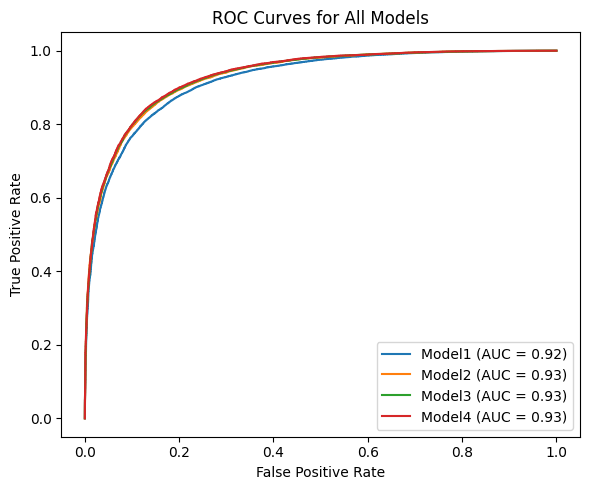

In [30]:
from sklearn.metrics import roc_curve, auc

# Generate ROC curves
plt.figure(figsize=(6, 5))

fpr1, tpr1, _ = roc_curve(y_true1, y_proba1)
auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, label=f'Model1 (AUC = {auc1:.2f})')

fpr2, tpr2, _ = roc_curve(y_true2, y_proba2)
auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, label=f'Model2 (AUC = {auc2:.2f})')


fpr3, tpr3, _ = roc_curve(y_true3, y_proba3)
auc3 = auc(fpr3, tpr3)
plt.plot(fpr3, tpr3, label=f'Model3 (AUC = {auc3:.2f})')


fpr4, tpr4, _ = roc_curve(y_true4, y_proba4)
auc4 = auc(fpr4, tpr4)
plt.plot(fpr4, tpr4, label=f'Model4 (AUC = {auc4:.2f})')

# Plot settings
# plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=300)
plt.show()

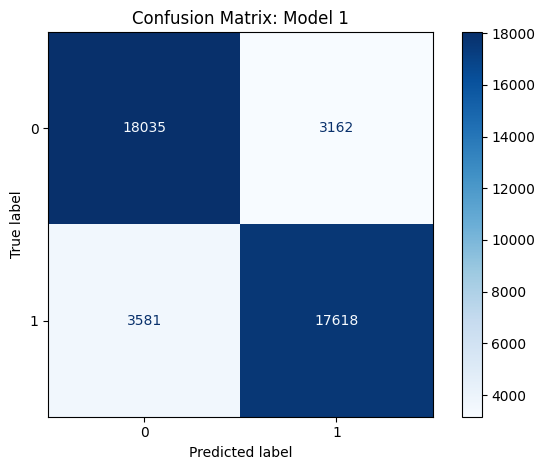

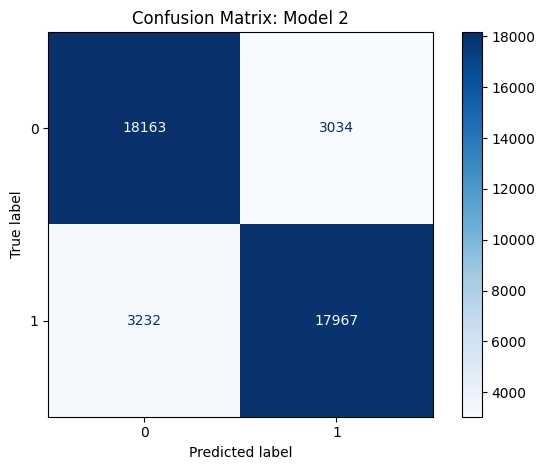

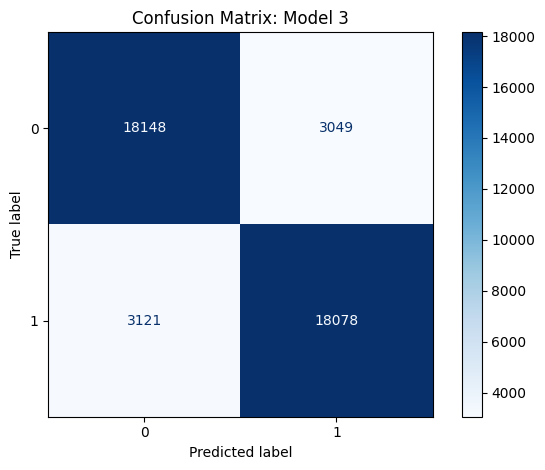

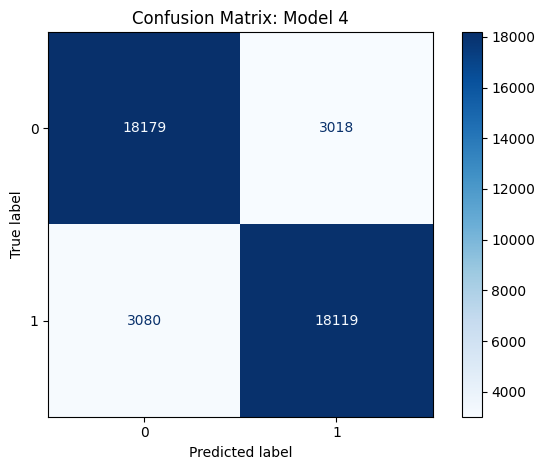

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save confusion matrices for all models
plot_confusion_matrix(y_true1, y_pred1, 'Confusion Matrix: Model 1', 'plots/cm_model1.png')
plot_confusion_matrix(y_true2, y_pred2, 'Confusion Matrix: Model 2', 'plots/cm_model2.png')
plot_confusion_matrix(y_true3, y_pred3, 'Confusion Matrix: Model 3', 'plots/cm_model3.png')
plot_confusion_matrix(y_true4, y_pred4, 'Confusion Matrix: Model 4', 'plots/cm_model4.png')

In [32]:
_, y_pred, _ = extract_metrics(best_model, best_test_dataloader, device)

submission_df = pd.DataFrame({'ID': test_data['ID'], 'Label': y_pred})
submission_df.to_csv('submission.csv', index=False)